# Session 26 01 2026
On that date I recorded a new session - I labeled the date so that I can validate the predictions of the current model

## Load model
First we are going to load the trained model from ML Flow

In [50]:
import sys
from pathlib import Path
import os
from dotenv import load_dotenv

load_dotenv()  # Load environment variables from .env file

project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from data_pipeline.database import save_to_db, initialize_tables, update_pipeline_run_status
from infra.db.database_utils import DatabaseFactory
import os
from infra.db.database_utils import DatabaseEngine, get_postgres_db_engine

import logging
logger = logging.getLogger(__name__)
import mlflow
from load_model import load_production_model


MLFLOW_TRACKING_URI = os.getenv("MLFLOW_BACKEND_STORE_URI", None)
if MLFLOW_TRACKING_URI is None:
    raise ValueError("MLFLOW_TRACKING_URI environment variable is not set.")
MODEL_NAME = os.getenv("MODEL_NAME", "HAR_xgboost")
MODEL_ALIAS = os.getenv("MODEL_ALIAS", "production")

db_engine = get_postgres_db_engine()

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

# LOAD MODEL AND SCALER
model, scaler = load_production_model(MODEL_NAME, MODEL_ALIAS)
print(f"Loaded model: {MODEL_NAME} with alias: {MODEL_ALIAS}")

if scaler:
    print("Scaler is available for data transformation.")
else:
    print("WARNING: No scaler loaded. Predictions on raw data may be incorrect.")

print(f"\nModel input schema:")
if hasattr(model, 'metadata') and model.metadata.signature:
    input_schema = model.metadata.signature.inputs
    print(f"  Expected features: {len(input_schema.input_names())}")
    print(f"  First 5 features: {input_schema.input_names()[:5]}")
else:
    print("  No signature found in model metadata")


2026-02-07 21:45:10,406 - azure.core.pipeline.policies.http_logging_policy - INFO - Request URL: 'https://harmlstorage.blob.core.windows.net/mlflow-artifacts?restype=REDACTED&comp=REDACTED&prefix=REDACTED&delimiter=REDACTED'
Request method: 'GET'
Request headers:
    'x-ms-version': 'REDACTED'
    'Accept': 'application/xml'
    'User-Agent': 'azsdk-python-storage-blob/12.28.0 Python/3.10.0 (Windows-10-10.0.26200-SP0)'
    'x-ms-date': 'REDACTED'
    'x-ms-client-request-id': 'e4ebb8d6-0465-11f1-b48b-e884a56c3c92'
    'Authorization': 'REDACTED'
No body was attached to the request


Loading model from MLflow URI: models:/HAR_xgboost@production


2026-02-07 21:45:10,606 - azure.core.pipeline.policies.http_logging_policy - INFO - Response status: 200
Response headers:
    'Transfer-Encoding': 'chunked'
    'Content-Type': 'application/xml'
    'Server': 'Windows-Azure-Blob/1.0 Microsoft-HTTPAPI/2.0'
    'x-ms-request-id': '63b9b7d6-801e-002d-5672-98cc57000000'
    'x-ms-client-request-id': 'e4ebb8d6-0465-11f1-b48b-e884a56c3c92'
    'x-ms-version': 'REDACTED'
    'Date': 'Sat, 07 Feb 2026 20:45:10 GMT'
2026-02-07 21:45:10,611 - azure.core.pipeline.policies.http_logging_policy - INFO - Request URL: 'https://harmlstorage.blob.core.windows.net/mlflow-artifacts?restype=REDACTED&comp=REDACTED&prefix=REDACTED&delimiter=REDACTED'
Request method: 'GET'
Request headers:
    'x-ms-version': 'REDACTED'
    'Accept': 'application/xml'
    'User-Agent': 'azsdk-python-storage-blob/12.28.0 Python/3.10.0 (Windows-10-10.0.26200-SP0)'
    'x-ms-date': 'REDACTED'
    'x-ms-client-request-id': 'e50b0ade-0465-11f1-a536-e884a56c3c92'
    'Authorizatio

2026-02-07 21:45:11,409 - azure.core.pipeline.policies.http_logging_policy - INFO - Response status: 200
Response headers:
    'Transfer-Encoding': 'chunked'
    'Content-Type': 'application/xml'
    'Server': 'Windows-Azure-Blob/1.0 Microsoft-HTTPAPI/2.0'
    'x-ms-request-id': 'b729b876-701e-0029-0972-984150000000'
    'x-ms-client-request-id': 'e565c04b-0465-11f1-bbf1-e884a56c3c92'
    'x-ms-version': 'REDACTED'
    'Date': 'Sat, 07 Feb 2026 20:45:10 GMT'
2026-02-07 21:45:11,417 - azure.core.pipeline.policies.http_logging_policy - INFO - Request URL: 'https://harmlstorage.blob.core.windows.net/mlflow-artifacts/745d24913ef64c76bcae21b1682e2868/artifacts/scaler.pkl'
Request method: 'GET'
Request headers:
    'x-ms-range': 'REDACTED'
    'x-ms-version': 'REDACTED'
    'Accept': 'application/xml'
    'User-Agent': 'azsdk-python-storage-blob/12.28.0 Python/3.10.0 (Windows-10-10.0.26200-SP0)'
    'x-ms-date': 'REDACTED'
    'x-ms-client-request-id': 'e585ef39-0465-11f1-911a-e884a56c3c92'


✓ Scaler loaded successfully
Loaded model: HAR_xgboost with alias: production
Scaler is available for data transformation.

Model input schema:
  No signature found in model metadata


model is loaded so time to run last processing and predictions

In [10]:
import pandas as pd

# data_to_predict = pd.read_json("E:\\src\\neat-calculator\\ml_monolith\\data_preprocessing\\merged_sensor_data_labeled.json")
data_to_predict = pd.read_csv(r"E:\src\neat-calculator\kaggle_data\human-activity-recognition-with-smartphones\test.csv")
data_to_predict.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.257178,-0.023285,-0.014654,-0.938404,-0.920091,-0.667683,-0.952501,-0.925249,-0.674302,-0.894088,...,-0.705974,0.006462,0.162920,-0.825886,0.271151,-0.720009,0.276801,-0.057978,2,STANDING
1,0.286027,-0.013163,-0.119083,-0.975415,-0.967458,-0.944958,-0.986799,-0.968401,-0.945823,-0.894088,...,-0.594944,-0.083495,0.017500,-0.434375,0.920593,-0.698091,0.281343,-0.083898,2,STANDING
2,0.275485,-0.026050,-0.118152,-0.993819,-0.969926,-0.962748,-0.994403,-0.970735,-0.963483,-0.939260,...,-0.640736,-0.034956,0.202302,0.064103,0.145068,-0.702771,0.280083,-0.079346,2,STANDING
3,0.270298,-0.032614,-0.117520,-0.994743,-0.973268,-0.967091,-0.995274,-0.974471,-0.968897,-0.938610,...,-0.736124,-0.017067,0.154438,0.340134,0.296407,-0.698954,0.284114,-0.077108,2,STANDING
4,0.274833,-0.027848,-0.129527,-0.993852,-0.967445,-0.978295,-0.994111,-0.965953,-0.977346,-0.938610,...,-0.846595,-0.002223,-0.040046,0.736715,-0.118545,-0.692245,0.290722,-0.073857,2,STANDING


this is raw data. first we need to run it through data processing pipeline

In [25]:
from data_pipeline.process_raw_data import process_raw_sensor_data
# generated_data_path = r"E:\src\neat-calculator\ml_monolith\data_preprocessing\merged_sensor_data_balanced_20260207.json"

# df = pd.read_json(generated_data_path)

# df.head()

# activities = df["label"]

# columns_to_drop = ["label"]
# feature_columns = [col for col in df.columns if col not in columns_to_drop]

# df_unlabeled = df[feature_columns]

# # save unlabeled data to a new JSON file
# unlabeled_data_path = r"E:\src\neat-calculator\ml_monolith\data_preprocessing\generated_data\merged_sensor_data_unlabeled_20260207.json"
# df_unlabeled.to_json(unlabeled_data_path, orient="records", lines=True)

# # save labels with timestamps to a csv with columns timestamp,label
labels_with_timestamps_path = r"E:\src\neat-calculator\ml_monolith\data_preprocessing\labels_with_timestamps_20260207.csv"
# df[["timestamp", "label"]].to_csv(labels_with_timestamps_path, index=False)



processed_data = process_raw_sensor_data(raw_data_file_dir=r"E:\src\neat-calculator\data_collection\recordings\sensor_data\SensorRecording\14012026",
                                            kaggle_csv_path="E:\\src\\neat-calculator\\ml_monolith\\kaggle.csv",
                                            labels_csv_path=r"E:\src\neat-calculator\ml_monolith\data_preprocessing\labels.csv")
processed_data.head()
# processed_data = data_to_predict.copy()  # Use the loaded data for prediction

2026-02-07 21:12:49,093 - data_pipeline.process_raw_data - INFO - Starting processing of raw data in directory: E:\src\neat-calculator\data_collection\recordings\sensor_data\SensorRecording\14012026
2026-02-07 21:12:49,093 - data_pipeline.process_raw_data - INFO - Using labels from: E:\src\neat-calculator\ml_monolith\data_preprocessing\labels.csv
2026-02-07 21:12:49,093 - data_pipeline.process_raw_data - INFO - Validating directory: E:\src\neat-calculator\data_collection\recordings\sensor_data\SensorRecording\14012026
2026-02-07 21:12:49,093 - data_pipeline.process_raw_data - INFO - Directory E:\src\neat-calculator\data_collection\recordings\sensor_data\SensorRecording\14012026 exists.
2026-02-07 21:12:49,093 - data_pipeline.process_raw_data - INFO - Path E:\src\neat-calculator\data_collection\recordings\sensor_data\SensorRecording\14012026 is a directory.
2026-02-07 21:12:49,093 - data_pipeline.process_raw_data - INFO - Directory E:\src\neat-calculator\data_collection\recordings\senso

{'accelerometerX': 'mean', 'accelerometerY': 'mean', 'accelerometerZ': 'mean', 'gyroscopeX': 'mean', 'gyroscopeY': 'mean', 'gyroscopeZ': 'mean'}
{'accelerometerX': 'mean', 'accelerometerY': 'mean', 'accelerometerZ': 'mean', 'gyroscopeX': 'mean', 'gyroscopeY': 'mean', 'gyroscopeZ': 'mean', 'label': 'first', 'timestamp': 'first'}


2026-02-07 21:12:51,523 - data_pipeline.process_raw_data - INFO - Median delta time: 0.02 seconds
2026-02-07 21:12:51,527 - data_pipeline.process_raw_data - INFO - Estimated frequency: 50.0 Hz
2026-02-07 21:12:51,527 - data_pipeline.process_raw_data - INFO - Resampling completed.
2026-02-07 21:12:51,529 - data_pipeline.process_raw_data - INFO - Columns after resampling: ['accelerometerX', 'accelerometerY', 'accelerometerZ', 'gyroscopeX', 'gyroscopeY', 'gyroscopeZ', 'label', 'timestamp', 'dt', 'dt_seconds']
2026-02-07 21:12:51,530 - data_pipeline.process_raw_data - INFO - Creating sliding windows with window size: 128, step size: 64
2026-02-07 21:12:51,534 - data_pipeline.process_raw_data - INFO - Identifying session breaks based on time gaps. A session means a singular recording session without big time gaps.
2026-02-07 21:12:51,535 - data_pipeline.process_raw_data - INFO - Number of sessions: 4
2026-02-07 21:12:51,641 - data_pipeline.process_raw_data - INFO - Sliding windows created.


                         dt_seconds  session_id
t                                              
2025-12-31 11:56:24.040        0.00           0
2025-12-31 11:56:24.060        0.02           0
2025-12-31 11:56:24.080        0.02           0
2025-12-31 11:56:24.100        0.02           0
2025-12-31 11:56:24.120        0.02           0
2025-12-31 11:56:24.140        0.02           0
2025-12-31 11:56:24.160        0.02           0
2025-12-31 11:56:24.180        0.02           0
2025-12-31 11:56:24.200        0.02           0
2025-12-31 11:56:24.220        0.02           0
Number of windows: 630
Window shape: (128, 6)
Example labels: ['CUTOUT' 'SITTING' 'STANDING' 'WALKING' 'WALKING_DOWNSTAIRS']


2026-02-07 21:12:56,286 - data_pipeline.process_raw_data - INFO - Shape of features: (630, 212)
2026-02-07 21:12:56,286 - data_pipeline.process_raw_data - INFO - Feature columns: Index(['tBodyAcc-mean()-X', 'tBodyAcc-std()-X', 'tBodyAcc-min()-X',
       'tBodyAcc-max()-X', 'tBodyAcc-energy()-X', 'tBodyAcc-entropy()-X',
       'tBodyAcc-mean()-Y', 'tBodyAcc-std()-Y', 'tBodyAcc-min()-Y',
       'tBodyAcc-max()-Y',
       ...
       'fBodyGyroMag-mean()', 'fBodyGyroMag-std()', 'fBodyGyroMag-energy()',
       'fBodyGyroMag-entropy()', 'fBodyGyroMag-meanFreq()',
       'fBodyGyroJerkMag-mean()', 'fBodyGyroJerkMag-std()',
       'fBodyGyroJerkMag-energy()', 'fBodyGyroJerkMag-entropy()',
       'fBodyGyroJerkMag-meanFreq()'],
      dtype='object', length=212)
2026-02-07 21:12:56,286 - data_pipeline.process_raw_data - INFO - Feature extraction completed.
2026-02-07 21:12:56,286 - data_pipeline.process_raw_data - INFO - Renaming features for clarity.
2026-02-07 21:12:56,301 - data_pipeline.proc

,tBodyAcc-mean()-X,tBodyAcc-std()-X,tBodyAcc-min()-X,tBodyAcc-max()-X,tBodyAcc-energy()-X,tBodyAcc-entropy()-X,tBodyAcc-mean()-Y,tBodyAcc-std()-Y,tBodyAcc-min()-Y,tBodyAcc-max()-Y,...,fBodyAccJerk-energy()-Z,fBodyAccJerk-entropy()-Z,fBodyAccJerk-meanFreq()-Z,fBodyAccMag-mean(),fBodyAccMag-std(),fBodyAccMag-energy(),fBodyAccMag-entropy(),fBodyAccMag-meanFreq(),Activity,timestamp
0,0.010747,0.106408,-0.292632,0.218670,0.011438,2.932824,0.049269,0.142684,-0.309676,0.509972,...,1412.254865,2.900774,13.112783,1.130863,3.119486,11.010047,0.312211,5.475927,STANDING,1.767182e+12
1,0.002934,0.048350,-0.120507,0.171882,0.002346,2.556511,0.000311,0.104843,-0.296942,0.384860,...,311.889001,2.915346,14.372163,0.829476,1.452664,2.798263,0.780496,6.983243,STANDING,1.767182e+12
2,0.031380,0.122447,-0.103824,0.447113,0.015978,2.171362,0.038681,0.135950,-0.323259,0.456014,...,543.671855,3.093359,12.509331,1.748472,4.045184,19.420670,0.672169,4.489402,STANDING,1.767182e+12
3,0.013981,0.241432,-0.335487,0.736180,0.058485,2.877906,-0.015107,0.159875,-0.310108,0.430368,...,1798.475672,2.931707,12.801162,2.238868,6.512288,47.422422,0.504128,4.389821,STANDING,1.767182e+12
4,0.137046,0.339028,-0.346681,0.727994,0.133722,2.916066,-0.017050,0.174443,-0.392456,0.247958,...,1765.307004,3.176732,12.639754,2.080297,8.358407,74.190604,0.114676,4.000860,STANDING,1.767182e+12


In [11]:
processed_data = data_to_predict.copy()# 
processed_data.describe()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject
count,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,...,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000
mean,0.273996,-0.017863,-0.108386,-0.613635,-0.508330,-0.633797,-0.641278,-0.522676,-0.637038,-0.462063,...,-0.277593,-0.598756,0.005264,0.003799,0.040029,-0.017298,-0.513923,0.074886,-0.048720,12.986427
std,0.060570,0.025745,0.042747,0.412597,0.494269,0.362699,0.385199,0.479899,0.357753,0.523916,...,0.317245,0.311042,0.336147,0.445077,0.634989,0.501311,0.509205,0.324300,0.241467,6.950984
min,-0.592004,-0.362884,-0.576184,-0.999606,-1.000000,-0.998955,-0.999417,-0.999914,-0.998899,-0.952357,...,-1.000000,-1.000000,-1.000000,-0.993402,-0.998898,-0.991096,-0.984195,-0.913704,-0.949228,2.000000
25%,0.262075,-0.024961,-0.121162,-0.990914,-0.973664,-0.976122,-0.992333,-0.974131,-0.975352,-0.934447,...,-0.517494,-0.829593,-0.130541,-0.282600,-0.518924,-0.428375,-0.829722,0.022140,-0.098485,9.000000
50%,0.277113,-0.016967,-0.108458,-0.931214,-0.790972,-0.827534,-0.937664,-0.799907,-0.817005,-0.852659,...,-0.311023,-0.683672,0.005188,0.006767,0.047113,-0.026726,-0.729648,0.181563,-0.010671,12.000000
75%,0.288097,-0.010143,-0.097123,-0.267395,-0.105919,-0.311432,-0.321719,-0.133488,-0.322771,-0.009965,...,-0.083559,-0.458332,0.146200,0.288113,0.622151,0.394387,-0.545939,0.260252,0.092373,18.000000
max,0.671887,0.246106,0.494114,0.465299,1.000000,0.489703,0.439657,1.000000,0.427958,0.786436,...,1.000000,1.000000,0.998898,0.986347,1.000000,1.000000,0.833180,1.000000,0.973113,24.000000


In [41]:
from json import load

from matplotlib import table
from data_pipeline.process_raw_data import rename_features
from infra.db.database_utils import get_postgres_db_engine

from dotenv import load_dotenv
load_dotenv()

engine = get_postgres_db_engine()

records_df = engine.get_records(table_name="training_data_labeled")

records_df.drop(columns=["timestamp"], inplace=True)

filtered_data = processed_data[records_df.columns]

filtered_data.head()

# from filtered data remove most of the rows with 'Standing' label to balance the dataset
standing_rows = filtered_data[filtered_data["Activity"] == "STANDING"]
# reduce the number of standing rows by to 100 rows
filtered_data = filtered_data.drop(standing_rows.index[:int(len(standing_rows)*0.9)])

# reduce number of WALKING rows to 50 rows
walking_rows = filtered_data[filtered_data["Activity"] == "WALKING"]
filtered_data = filtered_data.drop(walking_rows.index[:int(len(walking_rows)*0.5)])





In [42]:
filtered_data["Activity"].value_counts()

Activity
WALKING               67
STANDING              43
WALKING_DOWNSTAIRS    34
SITTING               21
Name: count, dtype: int64

Okay we processed the data so time to fit it

In [43]:
 # Use balanced data for prediction
import pandas as pd
from sklearn.preprocessing import LabelEncoder

columns_to_drop = ["Activity", "timestamp"]
feature_columns = [col for col in filtered_data.columns if col not in columns_to_drop]

# ORIGINAL RAW DATA
# Extract raw features from processed data
X= filtered_data[feature_columns]
y = filtered_data["Activity"].to_numpy()

print(f"Feature matrix shape: {X.shape}")
print(f"Raw Data range: [{X.min().min():.2f}, {X.max().max():.2f}]")

# APPLY SCALER IF AVAILABLE
if scaler:
    print("Applying scaler to input data...")
    # Filter columns that scaler expects
    # (Assuming scaler was fit on same feature set. If mismatch, we might need intersection)
    try:
        X_scaled = scaler.transform(X)
        print(f"Scaled Data range: [{X_scaled.min():.2f}, {X_scaled.max():.2f}]")
        # Make predictions using the SCALED data
        predictions = model.predict(X_scaled)          # Returns integer labels
        probabilities = model.predict_proba(X_scaled)  # Probability matrix
    except Exception as e:
        print(f"Scaling failed: {e}")
        print("Falling back to raw data (results may be poor)")
        predictions = model.predict(X)
        probabilities = model.predict_proba(X)
else:
    print("WARNING: Using raw unscaled data.")
    predictions = model.predict(X)
    probabilities = model.predict_proba(X)


print(f"\nPredictions shape: {predictions.shape}")
print(f"Probabilities shape: {probabilities.shape}")
print(f"\nFirst 5 predictions (integers): {predictions[:5]}")
print(f"First prediction probabilities: {probabilities[0]}")


Feature matrix shape: (165, 180)
Raw Data range: [-449.50, 58742.47]
Applying scaler to input data...
Scaled Data range: [-4.55, 83.43]

Predictions shape: (165,)
Probabilities shape: (165, 6)

First 5 predictions (integers): [3 4 4 4 4]
First prediction probabilities: [4.9406397e-03 5.3866487e-04 1.1262955e-02 9.6922386e-01 5.4202806e-03
 8.6136665e-03]


In [44]:
y

array(['WALKING_DOWNSTAIRS', 'WALKING_DOWNSTAIRS', 'WALKING_DOWNSTAIRS',
       'WALKING_DOWNSTAIRS', 'WALKING_DOWNSTAIRS', 'WALKING_DOWNSTAIRS',
       'WALKING_DOWNSTAIRS', 'WALKING_DOWNSTAIRS', 'WALKING_DOWNSTAIRS',
       'WALKING_DOWNSTAIRS', 'WALKING_DOWNSTAIRS', 'WALKING_DOWNSTAIRS',
       'WALKING_DOWNSTAIRS', 'WALKING_DOWNSTAIRS', 'WALKING_DOWNSTAIRS',
       'WALKING_DOWNSTAIRS', 'WALKING_DOWNSTAIRS', 'WALKING_DOWNSTAIRS',
       'WALKING_DOWNSTAIRS', 'WALKING_DOWNSTAIRS', 'WALKING_DOWNSTAIRS',
       'WALKING_DOWNSTAIRS', 'WALKING_DOWNSTAIRS', 'WALKING_DOWNSTAIRS',
       'WALKING_DOWNSTAIRS', 'SITTING', 'SITTING', 'SITTING', 'SITTING',
       'SITTING', 'SITTING', 'SITTING', 'SITTING', 'SITTING', 'SITTING',
       'SITTING', 'SITTING', 'WALKING', 'WALKING', 'WALKING', 'WALKING',
       'WALKING', 'WALKING', 'WALKING', 'WALKING', 'WALKING', 'WALKING',
       'WALKING', 'WALKING', 'WALKING', 'WALKING', 'WALKING', 'WALKING',
       'WALKING', 'WALKING', 'WALKING', 'WALKING', 

In [45]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

# The model was trained with LabelEncoder which sorts classes alphabetically by default
known_classes = ['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS']
le = LabelEncoder()
le.fit(known_classes)

# Inspect inputs
print(f"Type of y: {y.dtype}")
print(f"Type of predictions: {predictions.dtype}")
print(f"Unique values in predictions: {np.unique(predictions)}")

# Handle potential classes falling outside known classes
# It seems the model predicts a class (e.g., 6) that is outside the range 0-5.
# This can happen if the model was trained with more classes or if something is wrong.
# We will clip or map unknown classes to a placeholder or nearest valid class.

if np.issubdtype(predictions.dtype, np.number):
    print("Converting predictions from integers to string labels...")
    
    # Check for invalid labels
    invalid_mask = ~np.isin(predictions, np.arange(len(known_classes)))
    if invalid_mask.any():
        print(f"WARNING: Found {np.sum(invalid_mask)} predictions with invalid labels: {np.unique(predictions[invalid_mask])}")
        print("Mapping invalid labels to 'UNKNOWN' (or handling gracefully)")
        # Option 1: Clip to valid range (dangerous if mapping is wrong)
        # Option 2: Replace with dummy (-1) and handle transform manually
        
        # Here we'll convert manually to be safe
        pred_strings = []
        for p in predictions:
            if 0 <= p < len(known_classes):
                pred_strings.append(known_classes[p])
            else:
                pred_strings.append("UNKNOWN")
        predictions = np.array(pred_strings)
    else:
        predictions = le.inverse_transform(predictions.astype(int))

# Ensure y is string
y = y.astype(str)

print(f"First 5 ground truth: {y[:5]}")
print(f"First 5 predictions:  {predictions[:5]}")

Type of y: object
Type of predictions: int64
Unique values in predictions: [1 2 3 4]
Converting predictions from integers to string labels...
First 5 ground truth: ['WALKING_DOWNSTAIRS' 'WALKING_DOWNSTAIRS' 'WALKING_DOWNSTAIRS'
 'WALKING_DOWNSTAIRS' 'WALKING_DOWNSTAIRS']
First 5 predictions:  ['WALKING' 'WALKING_DOWNSTAIRS' 'WALKING_DOWNSTAIRS' 'WALKING_DOWNSTAIRS'
 'WALKING_DOWNSTAIRS']


In [46]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

# 1. Fix Label Mapping
# The model was trained with LabelEncoder which sorts classes alphabetically by default/standard HAR.
known_classes = ['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS']
le = LabelEncoder()
le.fit(known_classes)

# Inspect inputs
print(f"Type of y: {y.dtype}")
print(f"Type of predictions: {predictions.dtype}")

# Convert predictions (integers) back to string labels to match y
if np.issubdtype(predictions.dtype, np.number):
    print("Converting predictions from integers to string labels...")
    predictions = le.inverse_transform(predictions.astype(int))

# Ensure y is string
y = y.astype(str)

print(f"First 5 ground truth: {y[:5]}")
print(f"First 5 predictions:  {predictions[:5]}")


# 2. Check Feature Scaling (Likely Cause of Bad Performance)
# Kaggle HAR data is normalized to [-1, 1]. 
# Any values outside this range indicate a scaling mismatch using raw features.
print("\n--- Feature Scaling Check ---")
min_val = processed_data[feature_columns].min().min()
max_val = processed_data[feature_columns].max().max()
print(f"Min feature value: {min_val:.4f}")
print(f"Max feature value: {max_val:.4f}")

if min_val < -1.5 or max_val > 1.5:
    print("\n[WARNING] Feature values are outside the expected [-1, 1] range.")
    print("The model expects normalized data. Raw physical units will cause poor performance.")
    
    # Show top features violating range
    means = processed_data[feature_columns].mean()
    print("\nTop 5 features with highest mean values (likely unnormalized):")
    print(means.nlargest(5))
else:
    print("\n[OK] Feature values seem to be within normalized range.")

Type of y: <U18
Type of predictions: <U18
First 5 ground truth: ['WALKING_DOWNSTAIRS' 'WALKING_DOWNSTAIRS' 'WALKING_DOWNSTAIRS'
 'WALKING_DOWNSTAIRS' 'WALKING_DOWNSTAIRS']
First 5 predictions:  ['WALKING' 'WALKING_DOWNSTAIRS' 'WALKING_DOWNSTAIRS' 'WALKING_DOWNSTAIRS'
 'WALKING_DOWNSTAIRS']

--- Feature Scaling Check ---
Min feature value: -449.5000
Max feature value: 58742.4676

[WARNING] Feature values are outside the expected [-1, 1] range.
The model expects normalized data. Raw physical units will cause poor performance.

Top 5 features with highest mean values (likely unnormalized):
fBodyAccJerk-energy()-Y      2175.596768
fBodyAccJerk-energy()-Z      1680.783620
fBodyAccJerk-energy()-X      1617.112559
tBodyGyroJerkMag-energy()     191.797279
tBodyGyroJerk-energy()-Y       74.362572
dtype: float64


Accuracy: 0.4303

Classification Report:
                    precision    recall  f1-score   support

           SITTING       1.00      0.05      0.09        21
          STANDING       0.34      0.91      0.50        43
           WALKING       0.44      0.10      0.17        67
WALKING_DOWNSTAIRS       0.71      0.71      0.71        34

          accuracy                           0.43       165
         macro avg       0.62      0.44      0.37       165
      weighted avg       0.54      0.43      0.35       165



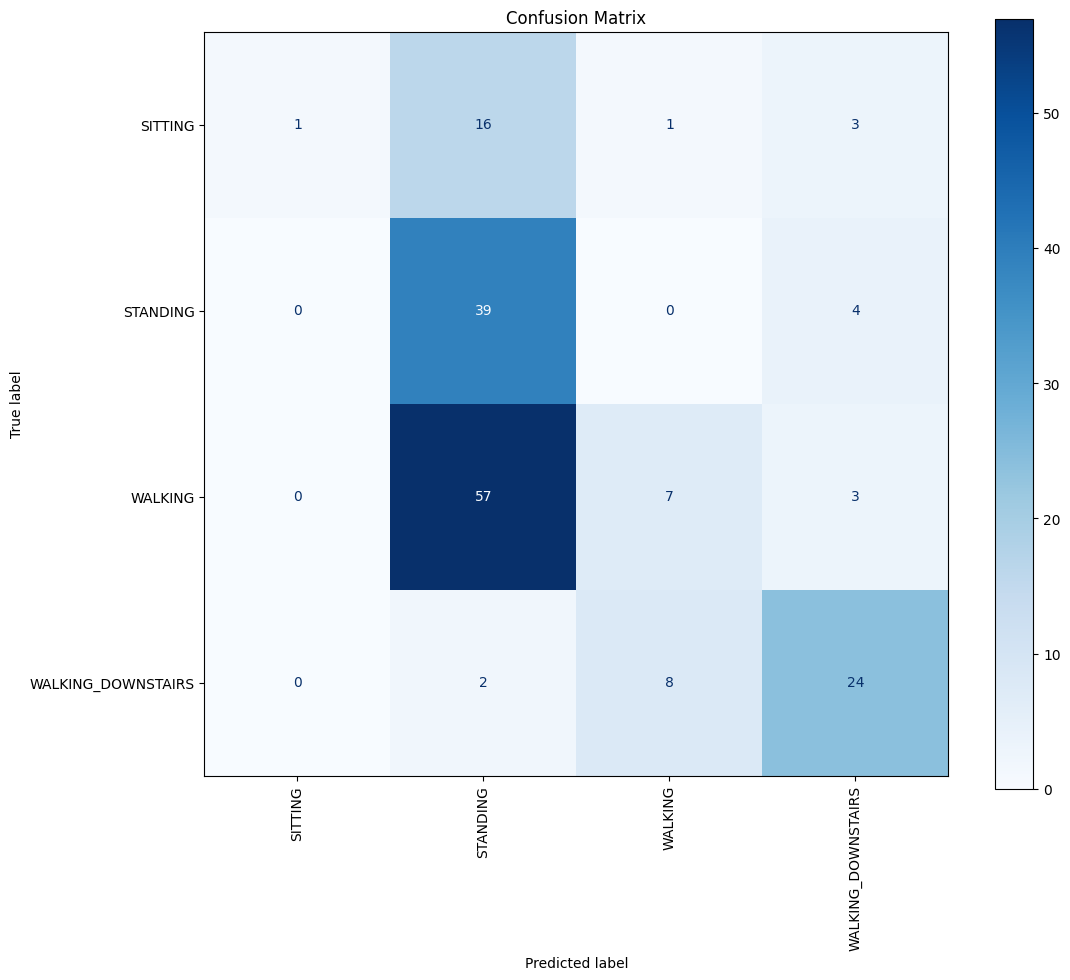

In [47]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Calculate accuracy
accuracy = accuracy_score(y, predictions)
print(f"Accuracy: {accuracy:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y, predictions))

# Confusion Matrix
# Ensure we capture all classes present in data and predictions
labels = np.unique(np.concatenate((y, predictions)))

fig, ax = plt.subplots(figsize=(12, 10))
cm = confusion_matrix(y, predictions, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', ax=ax, xticks_rotation='vertical')
plt.title('Confusion Matrix')
plt.show()

### Scaling Issue Identified
The model was trained on a combined dataset (Kaggle + Custom) where Kaggle data was scaled to [-1, 1] but Custom data was likely unscaled. This mixed distribution confuses the model.

**Next Steps:**
1. We have updated `train_model.py` to include `MinMaxScaler`.
2. You need to **re-run the training script** to generate a corrected model.
3. Then, reload the model here.


In [ ]:
# Re-training instructions
# To address the scaling mismatch, I've updated 'train_model.py' to scale your custom data to [-1, 1] before combining with Kaggle data.
# Please run the updated training script from the terminal:
# python ml_monolith/model_training/train_model.py


In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Debug: Visualize Feature Variance vs Labels to Check Alignment
# "Walking" should have high variance (std/energy), "Standing" should be near zero.

plt.figure(figsize=(20, 6))

# Choose a key feature representing intensity
metric = "tBodyAcc-std()-X"  # Standard deviation of body acceleration (Jerk/Energy proxy)

if metric not in filtered_data.columns:
    print(f"Feature {metric} not found. Using first available feature.")
    metric = filtered_data.columns[0]

# Plot the feature value
sns.lineplot(data=filtered_data, x="timestamp", y=metric, label=metric, color='blue', alpha=0.6)

# Overlay the ground truth labels
# We create diverse colors for activities
unique_activities = filtered_data["Activity"].unique()
palette = sns.color_palette("hsv", len(unique_activities))
activity_colors = dict(zip(unique_activities, palette))

# Create a "step" plot for labels (scaled to fit the graph)
# Mapping labels to a numeric y-value for visualization? 
# Better: shade the background or add a scatter plot.
# Let's add a scatter plot on top for the labels.

# Map activities to y-positions or just color
# We'll plot points at the top of the graph colored by activity
max_y = filtered_data[metric].max()
sns.scatterplot(data=filtered_data, x="timestamp", y=max_y * 1.1, hue="Activity", palette=palette, s=50, marker="o")

plt.title(f"Activity Signals Analysis: {metric} vs Time")
plt.ylabel("Signal Intensity (Std Dev)")
plt.xlabel("Time")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

# Histogram check
plt.figure(figsize=(10, 6))
sns.boxplot(data=filtered_data, x="Activity", y=metric)
plt.title(f"Distribution of {metric} by Activity Label")
plt.xticks(rotation=45)
plt.show()


ValueError: Could not interpret value `timestamp` for `x`. An entry with this name does not appear in `data`.

<Figure size 2000x600 with 0 Axes>